# WEEK 2 - Data Collection and Understanding

This section imports the Customer Personality Analysis dataset and examines its structure, variables, data types, and general characteristics.

In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedGroupKFold

In [2]:
# Load the Customer Personality Analysis dataset
df = pd.read_csv("../data/raw/marketing_campaign.csv", sep="\t")

# Display the first five rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
# Display the dimensions of the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2240
Number of columns: 29


In [4]:
# Display column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [5]:
# Check the number of missing values in each column
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [6]:
# Display summary statistics for the numberical variables
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
# Display the unique values for the categorical variables
print("Education:", df["Education"].unique())
print("Marital Status:", df["Marital_Status"].unique())

Education: <ArrowStringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str
Marital Status: <ArrowStringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str


In [8]:
# Display the frequency of each categorical value
print("Education Counts:")
print(df["Education"].value_counts())

print("\nMarital Status Counts:")
print(df["Marital_Status"].value_counts())

Education Counts:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital Status Counts:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [9]:
# Examine the distribution of the target variable
response_counts = df["Response"].value_counts()
response_percentages = df["Response"].value_counts(normalize=True) * 100

print("Response Counts:")
print(response_counts)

print("\nResponse Percentages:")
print(response_percentages.round(1))

Response Counts:
Response
0    1906
1     334
Name: count, dtype: int64

Response Percentages:
Response
0    85.1
1    14.9
Name: proportion, dtype: float64


In [10]:
# Check the unique values of the suspected constant columns
print("Z_CostContact unique values:")
print(df["Z_CostContact"].unique())

print("\nZ_Revenue unique values:")
print(df["Z_Revenue"].unique())

Z_CostContact unique values:
[3]

Z_Revenue unique values:
[11]


In [11]:
# Examine unusually early birth years
print("Earliest birth years:")
print(df["Year_Birth"].sort_values().head(10))

print("\nCustomers born before 1940:")
print(df[df["Year_Birth"] < 1940][["ID", "Year_Birth"]])

Earliest birth years:
239     1893
339     1899
192     1900
1950    1940
424     1941
1150    1943
415     1943
2084    1943
358     1943
1923    1943
Name: Year_Birth, dtype: int64

Customers born before 1940:
        ID  Year_Birth
192   7829        1900
239  11004        1893
339   1150        1899


In [12]:
# Examine the highest income values for potential outliers
print("Highest income values:")
print(df["Income"].sort_values(ascending=False).head(10))

print("\nCustomers with income above $150,000:")
print(df[df["Income"] > 150000][["ID", "Income"]].sort_values("Income", ascending=False))

Highest income values:
2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
Name: Income, dtype: float64

Customers with income above $150,000:
         ID    Income
2233   9432  666666.0
617    1503  162397.0
687    1501  160803.0
1300   5336  157733.0
164    8475  157243.0
1653   4931  157146.0
2132  11181  156924.0
655    5555  153924.0


In [13]:
# Examine acceptance counts for previous marketing campaigns
campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

print("Previous Campaign Acceptance Counts:")
for column in campaign_columns:
    print(f"\n{column}:")
    print(df[column].value_counts().sort_index())

Previous Campaign Acceptance Counts:

AcceptedCmp1:
AcceptedCmp1
0    2096
1     144
Name: count, dtype: int64

AcceptedCmp2:
AcceptedCmp2
0    2210
1      30
Name: count, dtype: int64

AcceptedCmp3:
AcceptedCmp3
0    2077
1     163
Name: count, dtype: int64

AcceptedCmp4:
AcceptedCmp4
0    2073
1     167
Name: count, dtype: int64

AcceptedCmp5:
AcceptedCmp5
0    2077
1     163
Name: count, dtype: int64


In [14]:
# Examine the range of customer enrollment dates
customer_dates = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y"
)

print("Earliest enrollment date:", customer_dates.min())
print("Latest enrollment date:", customer_dates.max())
print("Number of unique enrollment dates:", customer_dates.nunique())

Earliest enrollment date: 2012-07-30 00:00:00
Latest enrollment date: 2014-06-29 00:00:00
Number of unique enrollment dates: 663


In [15]:
# Check for duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


### Key Exploration Findings

- The dataset contains 2,240 customer records and 29 variables.
- Income is the only variable with missing values, with 24 missing observations.
- No duplicate rows were identified.
- Education and marital status contain several categorical groups, including a few uncommon marital status values.
- The target variable, Response, is imbalanced: 334 customers (14.9%) responded to the most recent campaign, while 1,906 (85.1%) did not.
- Z_CostContact and Z_Revenue are constant across all observations and therefore provide no variation.
- Three unusually early birth years (1893, 1899, and 1900) were identified for further investigation.
- Income contains several unusually high values, including one observation of $666,666.
- Customer enrollment dates range from July 2012 through June 2014.

---

## END OF WEEK 2 

WEEK 3 - START

In [16]:
# Check for customers with identical records under different IDs
feature_columns = [c for c in df.columns if c not in ("ID", "Response")]

print("Are all IDs unique?", df["ID"].is_unique)
print("Rows sharing an identical record with another row:",
      df.duplicated(subset=feature_columns, keep=False).sum())
print("Extra copies:", df.duplicated(subset=feature_columns).sum())

# Check whether any identical records have different Response labels
dup_rows = df[df.duplicated(subset=feature_columns, keep=False)]
conflicts = dup_rows.groupby(feature_columns, dropna=False)["Response"].nunique()
print("Identical records with conflicting Response labels:", (conflicts > 1).sum())

Are all IDs unique? True
Rows sharing an identical record with another row: 394
Extra copies: 201
Identical records with conflicting Response labels: 19


In [17]:
# Split into 80% training and 20% test
# - Stratified on Response so both sets keep the ~15% response rate
# - Group-aware so identical records always land in the same set

# Give each unique customer record a group number (duplicates share a number)
group_key = df[feature_columns].apply(lambda s: s.map(str)).agg("|".join, axis=1)
groups = pd.factorize(group_key)[0]

# Create 5 folds (~20% each) and use the first fold as the test set
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(splitter.split(df, y=df["Response"], groups=groups))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# Confirm no rows were lost and no duplicate group appears in both sets
assert len(train_df) + len(test_df) == len(df)
assert set(groups[train_idx]).isdisjoint(groups[test_idx])

print("Training set:", train_df.shape, "| Response rate:", round(train_df["Response"].mean() * 100, 1), "%")
print("Test set:", test_df.shape, "| Response rate:", round(test_df["Response"].mean() * 100, 1), "%")

Training set: (1792, 29) | Response rate: 14.9 %
Test set: (448, 29) | Response rate: 15.0 %


In [18]:
# Saving the split 
from pathlib import Path
Path("../data/processed").mkdir(parents=True, exist_ok=True)
train_df.to_csv("../data/processed/train.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

# All EDA below uses a copy of the training set 
eda = train_df.copy()

In [19]:
# Group the columns by type for use in the analysis below
spend_columns = ["MntWines", "MntFruits", "MntMeatProducts",
                 "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
channel_columns = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
                   "NumStorePurchases", "NumWebVisitsMonth"]
people_columns = ["Year_Birth", "Income", "Kidhome", "Teenhome", "Recency"]
numeric_columns = people_columns + spend_columns + channel_columns

Response
0    1525
1     267
Name: count, dtype: int64
Response rate: 14.9 %
Accuracy of always predicting 'no response': 85.1 %


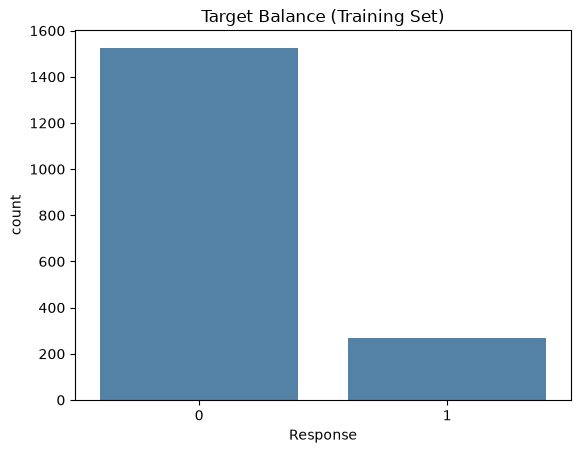

In [20]:
# 1. Target balance in the training set
print(eda["Response"].value_counts())
print("Response rate:", round(eda["Response"].mean() * 100, 1), "%")
print("Accuracy of always predicting 'no response':", round((1 - eda["Response"].mean()) * 100, 1), "%")

sns.countplot(x="Response", data=eda, color="steelblue")
plt.title("Target Balance (Training Set)")
plt.show()

In [21]:
# 2. Missing values and whether they relate to the target
print("Missing values:")
print(eda.isnull().sum()[eda.isnull().sum() > 0])

print("\nResponse rate by whether Income is missing:")
print(eda.groupby(eda["Income"].isnull())["Response"].agg(["count", "mean"]))

Missing values:
Income    16
dtype: int64

Response rate by whether Income is missing:
        count      mean
Income                 
False    1776  0.149775
True       16  0.062500


In [22]:
# 3. Outliers: count values outside 1.5 x IQR for each numeric column
def count_outliers(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    return ((column < q1 - 1.5 * iqr) | (column > q3 + 1.5 * iqr)).sum()

outlier_summary = pd.DataFrame({
    "min": eda[numeric_columns].min(),
    "median": eda[numeric_columns].median(),
    "max": eda[numeric_columns].max(),
    "skew": eda[numeric_columns].skew().round(2),
    "outliers": [count_outliers(eda[c].dropna()) for c in numeric_columns]
})
outlier_summary

,min,median,max,skew,outliers
Year_Birth,1899.0,1970.0,1996.0,-0.30,2
Income,1730.0,51741.5,666666.0,7.59,7
Kidhome,0.0,0.0,2.0,0.64,0
Teenhome,0.0,0.0,2.0,0.42,0
Recency,0.0,50.0,99.0,-0.01,0
MntWines,0.0,178.5,1493.0,1.13,25
MntFruits,0.0,8.0,199.0,2.07,182
MntMeatProducts,0.0,69.0,1725.0,2.09,133
MntFishProducts,0.0,12.0,259.0,1.85,175
MntSweetProducts,0.0,8.0,197.0,2.04,187


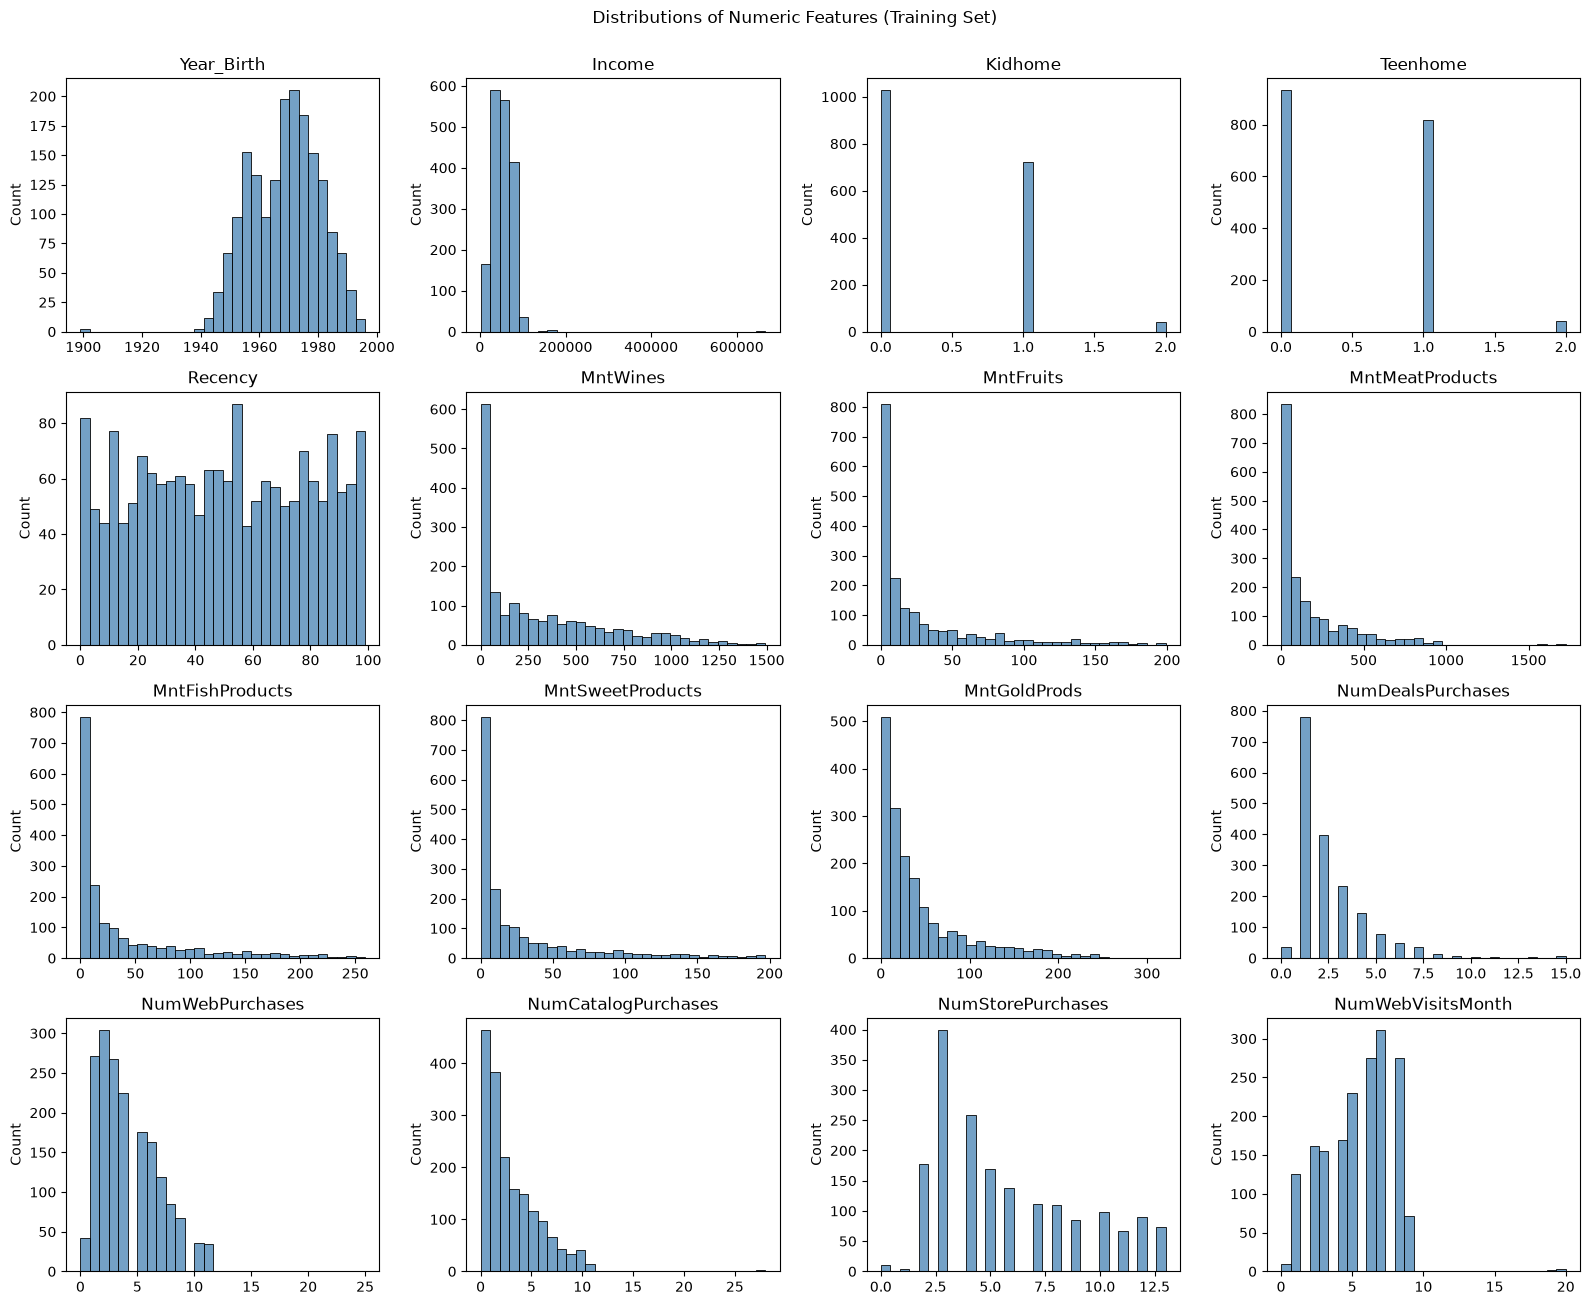

Share of customers with $0 spend by category:
MntWines             0.6 %
MntFruits           17.8 %
MntMeatProducts      0.1 %
MntFishProducts     16.8 %
MntSweetProducts    18.6 %
MntGoldProds         2.6 %
dtype: str


In [23]:
# 4. Univariate distributions: numeric features (training set)
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
for ax, col in zip(axes.flat, numeric_columns):
    sns.histplot(eda[col].dropna(), bins=30, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes.flat[len(numeric_columns):]:
    ax.set_visible(False)
plt.suptitle("Distributions of Numeric Features (Training Set)", y=1.0)
plt.tight_layout()
plt.show()

# Share of customers with zero spend in each category (explains the right skew)
print("Share of customers with $0 spend by category:")
print((eda[spend_columns] == 0).mean().mul(100).round(1).astype(str) + " %")

In [24]:
# 5. Response rate by categorical and count features
def response_table(column):
    table = eda.groupby(column)["Response"].agg(count="count", responders="sum", rate="mean")
    table["rate"] = (table["rate"] * 100).round(1)
    return table

overall_rate = eda["Response"].mean() * 100
print(f"Overall response rate: {overall_rate:.1f} %\n")
for column in ["Education", "Marital_Status", "Kidhome", "Teenhome", "Complain"]:
    print(f"--- {column} ---")
    print(response_table(column), "\n")

Overall response rate: 14.9 %

--- Education ---
            count  responders  rate
Education                          
2n Cycle      158          18  11.4
Basic          45           2   4.4
Graduation    906         124  13.7
Master        289          44  15.2
PhD           394          79  20.1 

--- Marital_Status ---
                count  responders  rate
Marital_Status                         
Absurd              2           1  50.0
Alone               2           1  50.0
Divorced          192          42  21.9
Married           685          75  10.9
Single            372          86  23.1
Together          475          47   9.9
Widow              62          14  22.6
YOLO                2           1  50.0 

--- Kidhome ---
         count  responders  rate
Kidhome                         
0         1027         173  16.8
1          723          92  12.7
2           42           2   4.8 

--- Teenhome ---
          count  responders  rate
Teenhome                         
0   

In [25]:
# 6. Prior campaign behaviour vs. Response
print("Response rate by acceptance of each earlier campaign:")
rows = []
for column in campaign_columns:
    grouped = eda.groupby(column)["Response"].mean() * 100
    rows.append({"campaign": column,
                 "accepted_n": int(eda[column].sum()),
                 "rate_if_accepted": round(grouped.get(1, np.nan), 1),
                 "rate_if_not": round(grouped.get(0, np.nan), 1)})
print(pd.DataFrame(rows).to_string(index=False))

eda_prior = eda[campaign_columns].sum(axis=1)
print("\nResponse rate by number of earlier campaigns accepted:")
print(eda.groupby(eda_prior.clip(upper=3).rename("prior_accepts (3 = 3+)"))["Response"]
         .agg(count="count", responders="sum", rate="mean")
         .assign(rate=lambda t: (t["rate"] * 100).round(1)))

responders = eda[eda["Response"] == 1]
print("\nShare of responders who accepted NO earlier campaign:",
      round((responders[campaign_columns].sum(axis=1) == 0).mean() * 100, 1), "%")

Response rate by acceptance of each earlier campaign:
    campaign  accepted_n  rate_if_accepted  rate_if_not
AcceptedCmp1         121              56.2         11.9
AcceptedCmp2          25              68.0         14.1
AcceptedCmp3         134              48.5         12.2
AcceptedCmp4         135              36.3         13.2
AcceptedCmp5         131              53.4         11.9

Response rate by number of earlier campaigns accepted:
                        count  responders  rate
prior_accepts (3 = 3+)                         
0                        1419         115   8.1
1                         258          82  31.8
2                          67          32  47.8
3                          48          38  79.2

Share of responders who accepted NO earlier campaign: 43.1 %


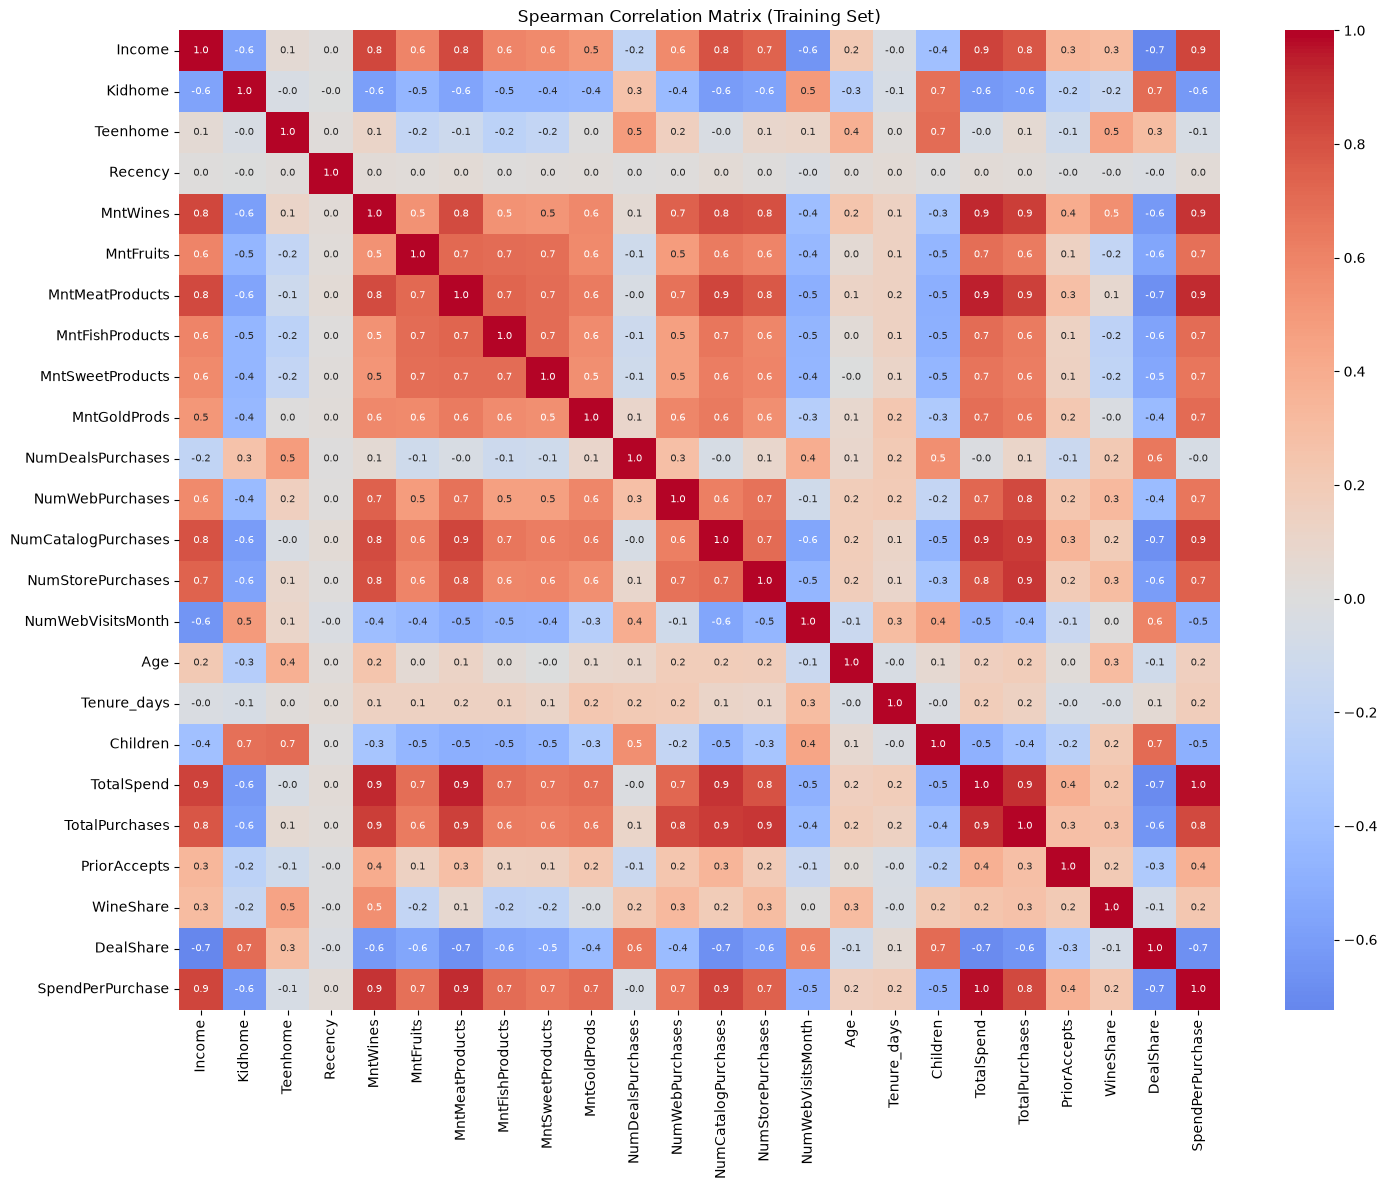

Feature pairs with |Spearman rho| >= 0.7:
          feature_1           feature_2   rho
         TotalSpend    SpendPerPurchase  0.98
    MntMeatProducts          TotalSpend  0.94
           MntWines          TotalSpend  0.93
    MntMeatProducts    SpendPerPurchase  0.92
         TotalSpend      TotalPurchases  0.91
           MntWines    SpendPerPurchase  0.90
NumCatalogPurchases          TotalSpend  0.89
  NumStorePurchases      TotalPurchases  0.89
NumCatalogPurchases      TotalPurchases  0.87
           MntWines      TotalPurchases  0.87
    MntMeatProducts      TotalPurchases  0.86
             Income          TotalSpend  0.86
NumCatalogPurchases    SpendPerPurchase  0.86
    MntMeatProducts NumCatalogPurchases  0.85
             Income    SpendPerPurchase  0.85
             Income            MntWines  0.84
     TotalPurchases    SpendPerPurchase  0.83
    NumWebPurchases      TotalPurchases  0.83
             Income     MntMeatProducts  0.83
           MntWines NumCatalogPurchase

In [26]:
# 7. Correlation between features

# Engineered features used by the correlation and consistency checks below
dates = pd.to_datetime(eda["Dt_Customer"], format="%d-%m-%Y")
reference_date = dates.max()
spend = eda[spend_columns].sum(axis=1)
purchases = eda[["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]].sum(axis=1)

eng = pd.DataFrame({
    "Age": reference_date.year - eda["Year_Birth"],
    "Tenure_days": (reference_date - dates).dt.days,
    "Children": eda["Kidhome"] + eda["Teenhome"],
    "TotalSpend": spend,
    "TotalPurchases": purchases,
    "PriorAccepts": eda[campaign_columns].sum(axis=1),
    "WineShare": eda["MntWines"] / spend.replace(0, np.nan),
    "DealShare": eda["NumDealsPurchases"] / purchases.replace(0, np.nan),
    "SpendPerPurchase": spend / purchases.replace(0, np.nan),
    "Response": eda["Response"],
})

corr_data = pd.concat([eda[numeric_columns].drop(columns="Year_Birth"), eng.drop(columns="Response")], axis=1)  # Age replaces Year_Birth
corr_data = corr_data.loc[:, ~corr_data.columns.duplicated()]
corr = corr_data.corr(method="spearman")

plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".1f", annot_kws={"size": 7})
plt.title("Spearman Correlation Matrix (Training Set)")
plt.tight_layout()
plt.show()

# List strongly correlated pairs (|rho| >= 0.7)
pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
             .stack().rename("rho").rename_axis(["feature_1", "feature_2"]).reset_index())
strong = pairs[pairs["rho"].abs() >= 0.7].sort_values("rho", key=abs, ascending=False)
print("Feature pairs with |Spearman rho| >= 0.7:")
print(strong.round(2).to_string(index=False))

In [27]:
# 8. Logical consistency checks (values that are possible individually but not together)
total_purchases = eng["TotalPurchases"]
checks = {
    "Spend > 0 but 0 web/catalog/store purchases": ((eng["TotalSpend"] > 0) & (total_purchases == 0)).sum(),
    "Deal purchases > total purchases": (eda["NumDealsPurchases"] > total_purchases).sum(),
    "Zero spend in every category": (eng["TotalSpend"] == 0).sum(),
    "Age over 100 (as of latest enrollment)": (eng["Age"] > 100).sum(),
    "Income missing": eda["Income"].isnull().sum(),
    "Income = 666,666 (likely placeholder)": (eda["Income"] == 666666).sum(),
    "Marital_Status in {Alone, Absurd, YOLO}": eda["Marital_Status"].isin(["Alone", "Absurd", "YOLO"]).sum(),
    "Complain = 1": eda["Complain"].sum(),
}
print(pd.Series(checks, name="rows in training set").to_string())

print("\nRows with implausible age or placeholder income:")
print(eda.loc[(eng["Age"] > 100) | (eda["Income"] == 666666),
              ["ID", "Year_Birth", "Income", "Education", "Marital_Status", "Response"]]
      .assign(TotalSpend=eng["TotalSpend"]).to_string(index=False))

print("\nIncome at or below the 1st percentile (possible data entry issues):")
low = eda["Income"].quantile(0.01)
print(eda.loc[eda["Income"] <= low, ["ID", "Income"]].assign(TotalSpend=eng["TotalSpend"])
      .sort_values("Income").to_string(index=False))

Spend > 0 but 0 web/catalog/store purchases     5
Deal purchases > total purchases                3
Zero spend in every category                    0
Age over 100 (as of latest enrollment)          2
Income missing                                 16
Income = 666,666 (likely placeholder)           1
Marital_Status in {Alone, Absurd, YOLO}         6
Complain = 1                                   17

Rows with implausible age or placeholder income:
  ID  Year_Birth   Income  Education Marital_Status  Response  TotalSpend
7829        1900  36640.0   2n Cycle       Divorced         0          65
1150        1899  83532.0        PhD       Together         0        1853
9432        1977 666666.0 Graduation       Together         0          62

Income at or below the 1st percentile (possible data entry issues):
   ID  Income  TotalSpend
 6862  1730.0           8
 5376  2447.0        1730
 9931  4023.0           9
10311  4428.0         359
 3955  4861.0           6
 5899  5648.0          49
 43

In [28]:
# 9. Duplicate profiles inside the training set (these stay together in CV folds)
train_key = eda[feature_columns].apply(lambda s: s.map(str)).agg("|".join, axis=1)
group_size = train_key.map(train_key.value_counts())
labels_per_group = eda.groupby(train_key)["Response"].nunique()

print("Training rows:", len(eda))
print("Distinct customer profiles:", train_key.nunique())
print("Rows that belong to a duplicate group:", (group_size > 1).sum())
print("Duplicate groups with conflicting Response labels:", (labels_per_group > 1).sum())
print("Response rate, duplicated rows:", round(eda.loc[group_size > 1, "Response"].mean() * 100, 1), "%")
print("Response rate, unique rows:", round(eda.loc[group_size == 1, "Response"].mean() * 100, 1), "%")

Training rows: 1792
Distinct customer profiles: 1630
Rows that belong to a duplicate group: 318
Duplicate groups with conflicting Response labels: 16
Response rate, duplicated rows: 15.7 %
Response rate, unique rows: 14.7 %
